In [1]:
import json
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
results_path = "/home/mahmoud/projects/RegionAwareVisionAssistant/results/EfficientAd/MVTecAD/wood/wood_val_scores.json"

with open(results_path, "r") as f:
    results = json.load(f)

df = pd.DataFrame(results)
df['image_name'] = df['image_path'].apply(lambda x: '_'.join(x.split('/')[-3:]))
df['anomaly_category'] = df['image_name'].apply(lambda x: x.split('_')[1])
df.head()

,image_path,gt_label,pred_score,pred_label,image_name,anomaly_category
0,/home/mahmoud/projects/RegionAwareVisionAssist...,True,1.000000,True,test_color_002.png,color
1,/home/mahmoud/projects/RegionAwareVisionAssist...,True,0.538814,True,test_color_004.png,color
2,/home/mahmoud/projects/RegionAwareVisionAssist...,True,1.000000,True,test_color_005.png,color
3,/home/mahmoud/projects/RegionAwareVisionAssist...,True,0.596908,True,test_color_006.png,color
4,/home/mahmoud/projects/RegionAwareVisionAssist...,True,0.817799,True,test_color_007.png,color


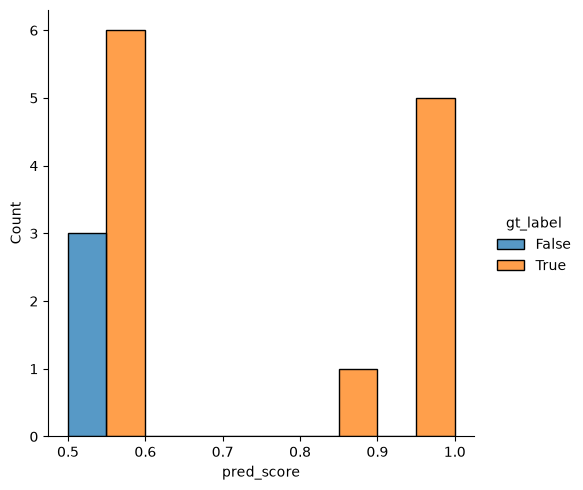

In [3]:
sns.displot(df, x='pred_score', hue='gt_label', multiple="dodge")

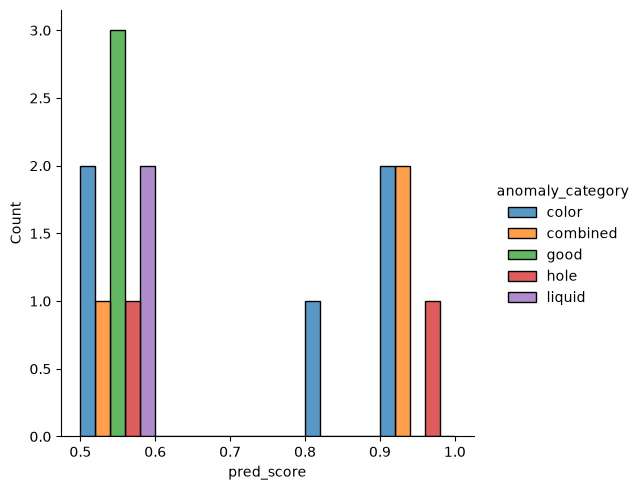

In [4]:
sns.displot(df, x='pred_score', hue='anomaly_category', multiple='dodge')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, '0.4993973970413208'),
  Text(1, 0, '0.4994696080684662'),
  Text(2, 0, '0.4997042715549469'),
  Text(3, 0, '0.5001757740974426'),
  Text(4, 0, '0.5007035732269287'),
  Text(5, 0, '0.5388144254684448'),
  Text(6, 0, '0.5450301170349121'),
  Text(7, 0, '0.5810014605522156'),
  Text(8, 0, '0.5969077348709106'),
  Text(9, 0, '0.8177985548973083'),
  Text(10, 0, '1.0')])

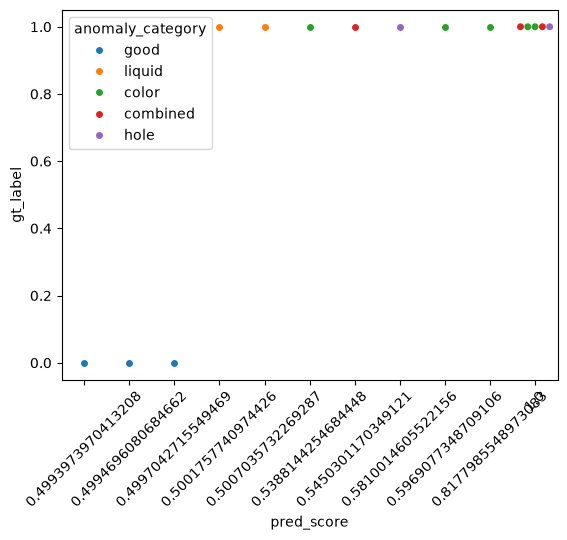

In [5]:
sns.swarmplot(df, x='pred_score', y='gt_label', hue='anomaly_category')
plt.xticks(rotation=45)

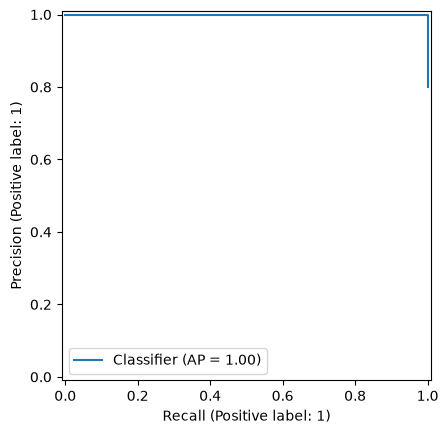

In [6]:
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay
precisions, recalls, thresholds = precision_recall_curve(df['gt_label'], df['pred_score'])
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
PrecisionRecallDisplay.from_predictions(df['gt_label'], df['pred_score'])
plt.show()

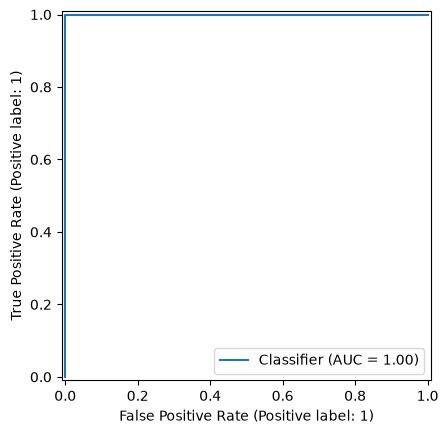

In [7]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(df['gt_label'], df['pred_score'])
plt.show()

In [8]:
import numpy as np

best_idx = np.nanargmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]
print(best_threshold, best_f1)

0.5001757740974426 1.0


In [9]:
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(df['gt_label'], df['pred_score'])

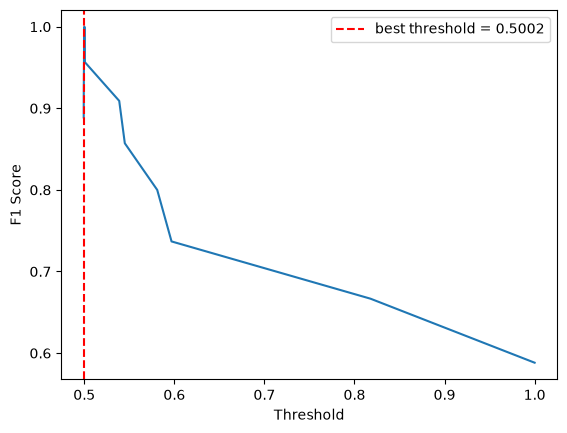

In [10]:
plt.plot(thresholds, f1_scores[:-1])
plt.axvline(best_threshold, color='red', linestyle='--', label=f'best threshold = {best_threshold:.4f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

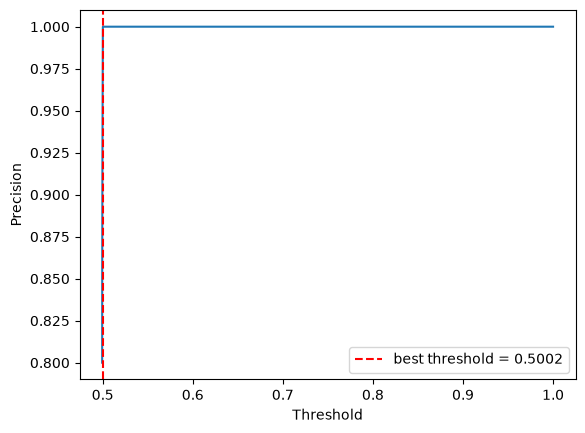

In [11]:
plt.plot(thresholds, precisions[:-1])
plt.axvline(best_threshold, color='red', linestyle='--', label=f'best threshold = {best_threshold:.4f}')
plt.xlabel('Threshold')
plt.ylabel('Precision')
plt.legend()
plt.show()

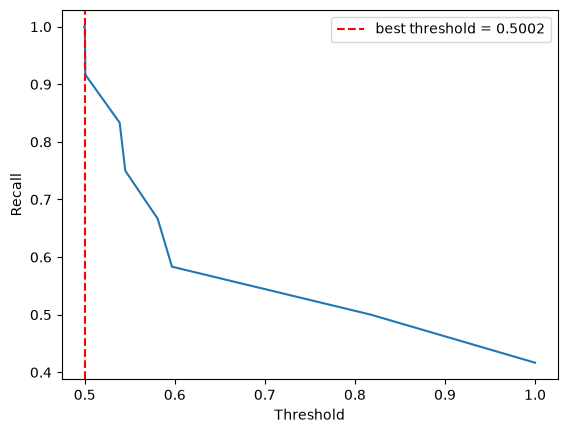

In [12]:
plt.plot(thresholds, recalls[:-1])
plt.axvline(best_threshold, color='red', linestyle='--', label=f'best threshold = {best_threshold:.4f}')
plt.xlabel('Threshold')
plt.ylabel('Recall')
plt.legend()
plt.show()

Threshold: 0.5001757740974426, AUC: 1.0, F1: 1.0


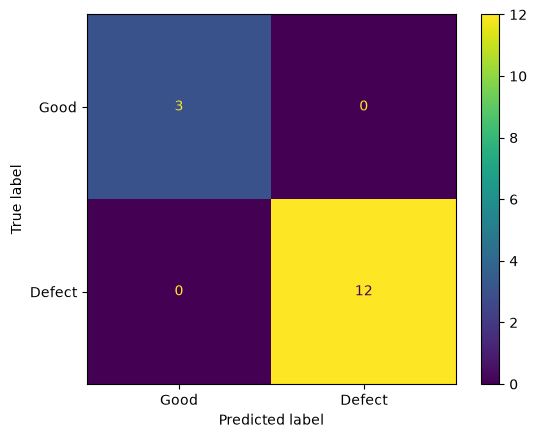

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
threshold = 0.499

pred_labels = df['pred_score'] >= best_threshold
print(f"Threshold: {best_threshold}, AUC: {auc}, F1: {best_f1}")
cm = confusion_matrix(df['gt_label'], pred_labels)
ConfusionMatrixDisplay(cm, display_labels=['Good', 'Defect']).plot()
plt.show()